In [ ]:
!pip install nibabel

import os
import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nib
import glob
import cv2
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Importaciones de Keras y TensorFlow de forma correcta
from tensorflow.keras.layers import Input, MaxPooling3D, Conv3D, Activation, concatenate, UpSampling3D, Conv3DTranspose
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from keras import backend as K

# Importar esto antes de usarlo para evitar el NameError
from tensorflow.compat.v1.logging import INFO, set_verbosity
set_verbosity(INFO)

from sklearn.model_selection import train_test_split

# Verificación de entorno
print("Versión de TensorFlow:", tf.__version__)
print("GPU Disponible: ", tf.config.list_physical_devices('GPU'))

Versión de TensorFlow: 2.20.0
GPU Disponible:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 2. CONEXIÓN A DRIVE Y DESCOMPRESIÓN RÁPIDA
from google.colab import drive
drive.mount('/content/drive')

# Descomprimir el ZIP
!unzip -n -q "/content/drive/MyDrive/DATA ALYSIS IT ACADEMY/ESPECIALIZACION/PROYECTO FINAL/datos.zip" -d /content/
print("¡Datos verificados y listos en el entorno local de Colab!")

Mounted at /content/drive
¡Datos verificados y listos en el entorno local de Colab!


## Exploracion dataset

In [ ]:
DATA_DIR = "/content/BraTS-PEDs-v1/Training"

# Comprobación de que Colab ve las carpetas de los pacientes
lista_pacientes = os.listdir(DATA_DIR)
print("Número de pacientes encontrados en el dataset de entrenamiento:", len(lista_pacientes))


Número de pacientes encontrados en el dataset de entrenamiento: 257


In [ ]:
def load_case(image_files_list, label_file):


    t1   = nib.load(image_files_list[0]).get_fdata()
    t1ce = nib.load(image_files_list[1]).get_fdata()
    t2   = nib.load(image_files_list[2]).get_fdata()
    flair = nib.load(image_files_list[3]).get_fdata()

    # 2. Las apilamos en el eje final para crear los canales (X, Y, Z, 4)
    image = np.stack([t1, t1ce, t2, flair], axis=-1)

    # 3. Cargamos la etiqueta de segmentación normalmente
    label = nib.load(label_file).get_fdata().astype(np.int16)

    return image, label

## Procesamiento previo de los datos : elaboracion de parches (subvolumenes)


In [ ]:
def get_sub_volume(image, label, orig_x=240, orig_y=240, orig_z=155,
                   output_x=160, output_y=160, output_z=16,
                   num_classes=5, deterministic=False):

    # --- 1. Determinamos las coordenadas de inicio ---
    if deterministic:
        # Modo Fijo (para validación/test)
        start_x = (orig_x - output_x) // 2
        start_y = (orig_y - output_y) // 2
        start_z = (orig_z - output_z) // 2
    else:
        # Modo Aleatorio (para entrenamiento)
        clases_presentes = [c for c in np.unique(label) if c > 0]

        if np.random.rand() < 0.7 and len(clases_presentes) > 0:
            clase_a_buscar = np.random.choice(clases_presentes)
            x_idx, y_idx, z_idx = np.where(label == clase_a_buscar)
            indice_azar = np.random.choice(len(x_idx))
            start_x = max(0, min(x_idx[indice_azar] - output_x // 2, orig_x - output_x))
            start_y = max(0, min(y_idx[indice_azar] - output_y // 2, orig_y - output_y))
            start_z = max(0, min(z_idx[indice_azar] - output_z // 2, orig_z - output_z))
        else:
            start_x = np.random.randint(0, orig_x - output_x + 1)
            start_y = np.random.randint(0, orig_y - output_y + 1)
            start_z = np.random.randint(0, orig_z - output_z + 1)

    # --- 2. Procesamiento final  ---
    # Python ejecutará esto siempre, después de calcular las coordenadas de arriba

    y = label[start_x: start_x + output_x, start_y: start_y + output_y, start_z: start_z + output_z]
    y = keras.utils.to_categorical(y, num_classes=num_classes)
    X = np.copy(image[start_x: start_x + output_x, start_y: start_y + output_y, start_z: start_z + output_z, :])

    X = np.moveaxis(X, 3, 0)
    y = np.moveaxis(y, 3, 0)
    y = y[1:, :, :, :]

    return X, y

### Estandarización

In [ ]:
def standardize(image):
    """
    Normaliza el parche restando la media y dividiendo por la desviación estándar.
    Cubre el caso extremo de parches vacíos o con desviación estándar igual a cero.
    """
    import numpy as np

    standardized_image = np.zeros_like(image, dtype=np.float32)


    for c in range(image.shape[0]):
        for z in range(image.shape[3]):
            slice_data = image[c, :, :, z]
            mean = np.mean(slice_data)
            std = np.std(slice_data)

            # Controlamos que la desviación estándar no sea cero para evitar dividir por 0
            if std > 0:
                centered_scaled = (slice_data - mean) / std
            else:
                # Si el parche está vacío o es uniforme, lo dejamos en 0 (ya centrado)
                centered_scaled = slice_data - mean

            # Ahora la variable EXISTE sí o sí en cualquier camino del if/else
            standardized_image[c, :, :, z] = centered_scaled

    return standardized_image


## DICE COEFFICIENT

### Dice coefficient para las 4 clases (Enhancing Tumor, Non-Enhancing Tumor (NET), Cystic Component (CC), Peritumoral Edema (ED))

In [ ]:
def dice_coefficient(y_true, y_pred, axis=(1, 2, 3),
                     epsilon=0.00001):
    """
    Compute mean dice coefficient over all abnormality classes.

    Args:
        y_true (Tensorflow tensor): tensor of ground truth values for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        y_pred (Tensorflow tensor): tensor of predictions for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        axis (tuple): spatial axes to sum over when computing numerator and
                      denominator of dice coefficient.
                      Hint: pass this as the 'axis' argument to the K.sum function.
        epsilon (float): small constant add to numerator and denominator to
                        avoid divide by 0 errors.
    Returns:
        dice_coefficient (float): computed value of dice coefficient.
    """

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###

    dice_numerator = 2 * tf.reduce_sum(y_true * y_pred , axis = axis) + epsilon
    dice_denominator = tf.reduce_sum(y_true, axis = axis ) + tf.reduce_sum(y_pred, axis = axis) + epsilon
    dice_coefficient = tf.reduce_mean(dice_numerator/dice_denominator)

    ### END CODE HERE ###

    return dice_coefficient



### Soft dice coefficient
explicacion:


In [ ]:
def soft_dice_loss(y_true, y_pred, axis=(1, 2, 3), epsilon=0.00001):
    """ Compute mean soft dice loss over all abnormality classes.

    Args:
        y_true (Tensorflow tensor): tensor of ground truth values for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        y_pred (Tensorflow tensor): tensor of soft predictions for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        axis (tuple): spatial axes to sum over when computing numerator and
                      denominator in formula for dice loss.
                      Hint: pass this as the 'axis' argument to the K.sum function.
        epsilon (float): small constant added to numerator and denominator to
                         avoid divide by 0 errors.
    Returns:
        dice_loss (float): computed value of dice loss.
    """

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###

    dice_numerator = 2 * tf.reduce_sum(y_true * y_pred, axis=axis) + epsilon
    dice_denominator = tf.reduce_sum(y_true ** 2, axis=axis) + tf.reduce_sum(y_pred ** 2, axis=axis) + epsilon
    dice_loss = 1 - tf.reduce_mean(dice_numerator / dice_denominator)

    ### END CODE HERE ###

    return dice_loss

Robust Dice loss


In [ ]:
def robust_dice_loss(y_true, y_pred):
    # Aseguramos estabilidad numérica
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Suavizado para que el gradiente fluya desde el inicio
    smooth = 1.0

    intersection = tf.reduce_sum(y_true * y_pred, axis=[2, 3, 4])
    union = tf.reduce_sum(y_true, axis=[2, 3, 4]) + tf.reduce_sum(y_pred, axis=[2, 3, 4])


    dice = (2. * intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(dice)

## Volume Data Generator

In [ ]:
class VolumeDataGenerator(keras.utils.Sequence):
    """
    Carga los volúmenes completos y extrae parches 3D en tiempo real.
    """
    def __init__(self, sample_list, base_dir, batch_size=1, shuffle=True,
                 dim=(160, 160, 16), num_channels=4, num_classes=4, verbose=1):
        self.sample_list = sorted(sample_list)
        self.base_dir = base_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.dim = dim
        self.num_channels = num_channels
        self.num_classes = num_classes
        self.verbose = verbose
        self.on_epoch_end()



    def on_epoch_end(self):
        """Actualiza y mezcla los índices al final de cada época"""
        self.indexes = np.arange(len(self.sample_list))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __len__(self):
        """Denota el número total de lotes (batches) por época"""
        return int(np.floor(len(self.sample_list) / self.batch_size))

    def __data_generation(self, list_IDs_temp):
        """Carga las imágenes completas y extrae los parches tridimensionales"""
        # Inicializamos las matrices del lote con ceros (formato channels_first)
        X = np.zeros((self.batch_size, self.num_channels, *self.dim), dtype=np.float32)
        y = np.zeros((self.batch_size, self.num_classes, *self.dim), dtype=np.float32)

        for i, ID in enumerate(list_IDs_temp):
            if self.verbose == 1:
                print(f"Generando parches 3D en tiempo real para: {ID}")

            # Construimos la ruta base hacia los archivos del paciente
            # C:\...\Training\BraTS-PED-00002-000\BraTS-PED-00002-000
            patient_folder_path = os.path.join(self.base_dir, ID)

            # Definimos las rutas exactas de tus 4 modalidades NIfTI
            image_files_list = [
                os.path.join(patient_folder_path, f"{ID}-t1n.nii.gz"),
                os.path.join(patient_folder_path, f"{ID}-t1c.nii.gz"),
                os.path.join(patient_folder_path, f"{ID}-t2f.nii.gz"),  # Secuencia FLAIR
                os.path.join(patient_folder_path, f"{ID}-t2w.nii.gz")
            ]
            label_file =os.path.join(patient_folder_path, f"{ID}-seg.nii.gz")

            # 1. Carga de los volúmenes completos usando tu función original
            img_completa, mask_completa = load_case(image_files_list, label_file)

            # 2. Extracción del parche usando la función get_sub_volume
            # Le pasamos num_classes=5 para el to_categorical antes de que elimine el fondo
            parche_x, parche_y = get_sub_volume(
                img_completa, mask_completa,
                orig_x=240, orig_y=240, orig_z=155,
                output_x=self.dim[0], output_y=self.dim[1], output_z=self.dim[2],
                num_classes=5,
                deterministic=(not self.shuffle)
            )

            # 3. Normalizacion de los parches de las imagenes
            parche_x_normalizado= standardize(parche_x)

            # 4. Almacenamos el parche procesado dentro del lote actual
            X[i] = parche_x_normalizado
            y[i] = parche_y

        return X, y

    def __getitem__(self, index):
        """Genera un lote completo de datos cuando Keras lo solicita"""
        indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]
        sample_list_temp = [self.sample_list[k] for k in indexes]
        X, y = self.__data_generation(sample_list_temp)
        return X, y

## Segmentacion Data en Train - Validation - Test

In [ ]:
import os
from sklearn.model_selection import train_test_split

# 1. Defines la ruta a tu carpeta
ruta_train = "/content/BraTS-PEDs-v1/Training"


# 2. Obtienes las listas de pacientes de cada directorio
pacientes_completos = sorted(os.listdir(ruta_train))  # los 257 pacientes


# 3. Primer corte: Reservamos el 20% del total para (Validación + Test)
# El 80% restante se guarda directamente en 'pacientes_train' (~205 niños)
pacientes_train, pacientes_temporales = train_test_split(
    pacientes_completos,
    test_size=0.20,          # 20% para el subconjunto de validación/test
    random_state=42          # Para que no cambie al volver a ejecutar
)
#4. Segundo corte: Ese 20% temporal lo dividimos a la mitad (50/50)
# Así obtenemos un 10% puro para Validación (~26 niños) y un 10% puro para Test (~26 niños)
pacientes_val, pacientes_test = train_test_split(
    pacientes_temporales,
    test_size= 0.50,
    random_state=42
)
# Control de inventario en tu consola
print(f"Pipeline configurado correctamente:")
print(f" └── Train: {len(pacientes_train)} pacientes (Ruta: {ruta_train})")
print(f" └── Validation: {len(pacientes_val)} pacientes (Ruta: {ruta_train})")
print(f" └── Test Final: {len(pacientes_test)} pacientes (Ruta: {ruta_train})")
print(f"\nTotal pacientes utilizados con etiquetas: {len(pacientes_train) + len(pacientes_val) + len(pacientes_test)}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/BraTS-PEDs-v1/Training'

In [ ]:
# Generador de entrenamiento: apunta a la carpeta Training
train_generator = VolumeDataGenerator(
   sample_list=pacientes_train,          # Tu lista con el 70-80% de pacientes de entrenamiento
    base_dir=ruta_train,                  # Ruta a la carpeta física 'Training'
    batch_size=2,                         # Lote de 2 (ideal para no saturar la memoria RAM/VRAM en 3D)
    shuffle=True,                         # Mezclar los pacientes en cada época para un mejor aprendizaje
    dim=(160, 160, 16),                   # El tamaño exacto de tus parches tridimensionales
    num_channels=4,                       # Las 4 modalidades de entrada (T1, T1c, FLAIR, T2w)
    num_classes=4                         # 🌟 Tus 4 clases de tejido (sin el background)
)

# Generador de validación: apunta a la carpeta Validation, pero solo usa su mitad
val_generator = VolumeDataGenerator(
    sample_list= pacientes_val,
    base_dir=ruta_train,
    batch_size=1,                         # Lote de 2 (ideal para no saturar la memoria RAM/VRAM en 3D)
    shuffle=False,                         # Mezclar los pacientes en cada época para un mejor aprendizaje
    dim=(160, 160, 16),                   # El tamaño exacto de tus parches tridimensionales
    num_channels=4,                       # Las 4 modalidades de entrada (T1, T1c, FLAIR, T2w)
    num_classes=4                         # 🌟 Tus 4 clases de tejido (sin el background)
)



# Generador de test: apunta a la carpeta Validation, usando la otra mitad guardada
test_generator = VolumeDataGenerator(
    sample_list= pacientes_test,
    base_dir=ruta_train,
    batch_size=1,                         # Lote de 2 (ideal para no saturar la memoria RAM/VRAM en 3D)
    shuffle=False,                         # Mezclar los pacientes en cada época para un mejor aprendizaje
    dim=(160, 160, 16),                   # El tamaño exacto de tus parches tridimensionales
    num_channels=4,                       # Las 4 modalidades de entrada (T1, T1c, FLAIR, T2w)
    num_classes=4
)

## Modelo

In [ ]:
from tensorflow.keras.layers import Conv3D, BatchNormalization, Activation, LeakyReLU

def create_convolution_block(input_layer, n_filters, batch_normalization=True, # Cambiado a True por defecto
                             kernel=(3, 3, 3), padding='same', strides=(1, 1, 1)):

    # 1. Convolución
    # Importante: si usas BatchNormalization, el bias no aporta nada, mejor quitarlo (use_bias=False)
    x = Conv3D(n_filters, kernel, padding=padding, strides=strides, use_bias=False, data_format="channels_first")(input_layer)

    # 2. Normalización
    if batch_normalization:
        x = BatchNormalization(axis=1)(x)

    # 3. Activación (Usar LeakyReLU es mejor que ReLU para evitar neuronas muertas)
    x = LeakyReLU(negative_slope=0.1)(x)

    return x



def get_up_convolution(n_filters, pool_size, kernel_size=(2, 2, 2),
                       strides=(2, 2, 2),
                       deconvolution=False):
    if deconvolution:

        return Conv3DTranspose(filters=n_filters,
                               kernel_size=kernel_size,
                               strides=strides,
                               padding='same',
                               data_format="channels_first")
    else:
        return UpSampling3D(size=pool_size,
                            data_format="channels_first")


def unet_model_3d(loss_function, input_shape=(4, 160, 160, 16),
                  pool_size=(2, 2, 2), n_labels=4,
                  initial_learning_rate=0.0001,
                  deconvolution=False, depth=4, n_base_filters=32,
                  include_label_wise_dice_coefficients=False, metrics=[],
                  batch_normalization=True, activation_name="sigmoid"):
    """
    Builds the 3D UNet Keras model.f
    :param metrics: List metrics to be calculated during model training (default is dice coefficient).
    :param include_label_wise_dice_coefficients: If True and n_labels is greater than 1, model will report the dice
    coefficient for each label as metric.
    :param n_base_filters: The number of filters that the first layer in the convolution network will have. Following
    layers will contain a multiple of this number. Lowering this number will likely reduce the amount of memory required
    to train the model.
    :param depth: indicates the depth of the U-shape for the model. The greater the depth, the more max pooling
    layers will be added to the model. Lowering the depth may reduce the amount of memory required for training.
    :param input_shape: Shape of the input data (n_chanels, x_size, y_size, z_size). The x, y, and z sizes must be
    divisible by the pool size to the power of the depth of the UNet, that is pool_size^depth.
    :param pool_size: Pool size for the max pooling operations.
    :param n_labels: Number of binary labels that the model is learning.
    :param initial_learning_rate: Initial learning rate for the model. This will be decayed during training.
    :param deconvolution: If set to True, will use transpose convolution(deconvolution) instead of up-sampling. This
    increases the amount memory required during training.
    :return: Untrained 3D UNet Model
    """
    inputs = Input(input_shape)
    current_layer = inputs
    levels = list()

    # add levels with max pooling
    for layer_depth in range(depth):
        layer1 = create_convolution_block(input_layer=current_layer,
                                          n_filters=n_base_filters * (
                                                  2 ** layer_depth),
                                          batch_normalization=batch_normalization)
        layer2 = create_convolution_block(input_layer=layer1,
                                          n_filters=n_base_filters * (
                                                  2 ** layer_depth) * 2,
                                          batch_normalization=batch_normalization)
        if layer_depth < depth - 1:
            current_layer = MaxPooling3D(pool_size=pool_size, data_format="channels_first")(layer2)
            levels.append([layer1, layer2, current_layer])
        else:
            current_layer = layer2
            levels.append([layer1, layer2])

    # add levels with up-convolution or up-sampling
    for layer_depth in range(depth - 2, -1, -1):
        up_convolution = get_up_convolution(pool_size=pool_size,
                                            deconvolution=deconvolution,
                                            n_filters=
                                            current_layer.shape[1])(
            current_layer)
        concat = concatenate([up_convolution, levels[layer_depth][1]], axis=1)
        current_layer = create_convolution_block(
            n_filters=levels[layer_depth][1].shape[1],
            input_layer=concat, batch_normalization=batch_normalization)
        current_layer = create_convolution_block(
            n_filters=levels[layer_depth][1].shape[1],
            input_layer=current_layer,
            batch_normalization=batch_normalization)

    final_convolution = Conv3D(n_labels, (1, 1, 1),data_format="channels_first")(current_layer)
    act = Activation(activation_name)(final_convolution)
    model = Model(inputs=inputs, outputs=act)

    if not isinstance(metrics, list):
        metrics = [metrics]

    model.compile(optimizer=Adam(learning_rate=initial_learning_rate), loss=loss_function,
                  metrics=metrics)
    return model

In [ ]:
model = unet_model_3d(
    loss_function=robust_dice_loss,       # La función matemática que definimos
    input_shape=(4, 160, 160, 16),      # 4 canales y parches de 160x160x16
    n_labels=4,                         # 4 clases de tejido tumoral
    activation_name="sigmoid",
    metrics=[dice_coefficient]          # métrica visual
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 4, 160,    │          0 │ -                 │
│ (InputLayer)        │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_15 (Conv3D)  │ (None, 32, 160,   │      3,456 │ input_layer_1[0]… │
│                     │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 160,   │        128 │ conv3d_15[0][0]   │
│ (BatchNormalizatio… │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 32, 160,   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_16 (Conv3D)  │ (None, 64, 160,   │     55,296 │ leaky_re_lu_14[0… │
│                     │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 160,   │        256 │ conv3d_16[0][0]   │
│ (BatchNormalizatio… │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 64, 160,   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 64, 80,    │          0 │ leaky_re_lu_15[0… │
│ (MaxPooling3D)      │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_17 (Conv3D)  │ (None, 64, 80,    │    110,592 │ max_pooling3d_3[… │
│                     │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 80,    │        256 │ conv3d_17[0][0]   │
│ (BatchNormalizatio… │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 64, 80,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_18 (Conv3D)  │ (None, 128, 80,   │    221,184 │ leaky_re_lu_16[0… │
│                     │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 80,   │        512 │ conv3d_18[0][0]   │
│ (BatchNormalizatio… │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_17      │ (None, 128, 80,   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_4     │ (None, 128, 40,   │          0 │ leaky_re_lu_17[0… │
│ (MaxPooling3D)      │ 40, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_19 (Conv3D)  │ (None, 128, 40,   │    442,368 │ max_pooling3d_4[… │
│                     │ 40, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 40,   │        512 │ conv3d_19[0][0] 

 Total params: 16,325,380 (62.28 MB)

 Trainable params: 16,320,708 (62.26 MB)

 Non-trainable params: 4,672 (18.25 KB)

### Entrenamiento del modelo

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# 1. CONFIGURACIÓN DE LOS GUARDIANES (CALLBACKS)

# Ruta en tu Drive donde se guardará el modelo de forma automática
checkpoint_path = "/content/drive/MyDrive/DATA ALYSIS IT ACADEMY/mejor_modelo_unet3d.keras"

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',        # Se fija en el error de validación
    save_best_only=True,       # SOLO guarda si el modelo ha mejorado respecto al epoch anterior
    mode='min',                # Buscamos minimizar el loss
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,                # Si pasa 7 épocas seguidas sin mejorar, frena el entrenamiento
    mode='min',
    restore_best_weights=True, # Al frenar, te devuelve los pesos del mejor epoch histórico
    verbose=1
)

# Unimos los dos guardianes en una lista
mis_callbacks = [checkpoint, early_stop]



# 🔥 MOCK TEST (PRUEBA DE HUMO) - EJECUTAR SOLO PARA VALIDAR EL PIPELINE


#print("Lanzando Mock Test rápido")

# Forzamos parámetros mínimos para que termine de inmediato
#mock_epochs = 2
#mock_steps_train = 3
#mock_steps_val = 2

#mock_history = model.fit(
    #train_generator,
    #steps_per_epoch=mock_steps_train,
    #validation_data=val_generator,
    #validation_steps=mock_steps_val,
    #epochs=mock_epochs,
    #verbose=1  # Para ver la barra de progreso en directo
#)

#print("¡MOCK TEST COMPLETADO CON ÉXITO!")



# 2. ENTRENAMIENTO REAL Y DEFINITIVO



pasos_entrenamiento = 103 # 205 pacientes / batch_size 2 = 103 pasos
pasos_validacion = 26       # 26 pacientes / batch_size 1 = 26 pasos


print("¡Arrancando el entrenamiento definitivo de la U-Net 3D...!")

history = model.fit(
    train_generator,
    steps_per_epoch=pasos_entrenamiento,
    validation_data=val_generator,
    validation_steps=pasos_validacion,
    epochs=30,
    callbacks=mis_callbacks,             # Conectamos los guardianes
    verbose=1
)



¡Arrancando el entrenamiento definitivo de la U-Net 3D...!
Generando parches 3D en tiempo real para: BraTS-PED-00113-000


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Generando parches 3D en tiempo real para: BraTS-PED-00155-000
Generando parches 3D en tiempo real para: BraTS-PED-00097-000
Generando parches 3D en tiempo real para: BraTS-PED-00196-000
Epoch 1/30
Generando parches 3D en tiempo real para: BraTS-PED-00075-000
Generando parches 3D en tiempo real para: BraTS-PED-00129-000
Generando parches 3D en tiempo real para: BraTS-PED-00132-000
Generando parches 3D en tiempo real para: BraTS-PED-00212-000
  1/103 ━━━━━━━━━━━━━━━━━━━━ 1:37:12 57s/step - dice_coefficient: 0.0121 - loss: 0.9894Generando parches 3D en tiempo real para: BraTS-PED-00230-000
  2/103 ━━━━━━━━━━━━━━━━━━━━ 30s 299ms/step - dice_coefficient: 0.0133 - loss: 0.9883  Generando parches 3D en tiempo real para: BraTS-PED-00027-000
Generando parches 3D en tiempo real para: BraTS-PED-00084-000
  3/103 ━━━━━━━━━━━━━━━━━━━━ 3:57 2s/step - dice_coefficient: 0.0140 - loss: 0.9876  Generando parches 3D en tiempo real para: BraTS-PED-00139-000
Generando parches 3D en tiempo real para: BraTS-

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Generando parches 3D en tiempo real para: BraTS-PED-00118-000
 83/103 ━━━━━━━━━━━━━━━━━━━━ 1:23 4s/step - dice_coefficient: 0.0597 - loss: 0.8888Generando parches 3D en tiempo real para: BraTS-PED-00194-000
Generando parches 3D en tiempo real para: BraTS-PED-00033-000
 84/103 ━━━━━━━━━━━━━━━━━━━━ 1:19 4s/step - dice_coefficient: 0.0597 - loss: 0.8888Generando parches 3D en tiempo real para: BraTS-PED-00088-000
Generando parches 3D en tiempo real para: BraTS-PED-00185-000
 85/103 ━━━━━━━━━━━━━━━━━━━━ 1:14 4s/step - dice_coefficient: 0.0598 - loss: 0.8888Generando parches 3D en tiempo real para: BraTS-PED-00196-000
Generando parches 3D en tiempo real para: BraTS-PED-00238-000
 86/103 ━━━━━━━━━━━━━━━━━━━━ 1:10 4s/step - dice_coefficient: 0.0598 - loss: 0.8887Generando parches 3D en tiempo real para: BraTS-PED-00183-000
Generando parches 3D en tiempo real para: BraTS-PED-00177-000
 87/103 ━━━━━━━━━━━━━━━━━━━━ 1:0

# Carga del modelo

In [ ]:
import tensorflow as tf
import nibabel as nib
import numpy as np

model_path = "/content/drive/MyDrive/DATA ALYSIS IT ACADEMY/mejor_modelo_unet3d.keras"

# 1. Cargamos el modelo sin compilar para evitar errores de funciones custom
model = tf.keras.models.load_model(model_path, compile=False)
print("Modelo cargado exitosamente.")

# 2. Imprime la forma de entrada para confirmar de una vez por todas qué espera el modelo
print(f"Forma de entrada que el modelo necesita: {model.input_shape}")

Modelo cargado exitosamente.
Forma de entrada que el modelo necesita: (None, 4, 160, 160, 16)


In [ ]:
def evaluar_por_clases(model, generator):
    dice_resultados = {1 : [], 2 : [], 3 : [], 4 :[]}

    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        prediccion = model.predict(X_batch, verbose=0)

        # Aplicamos un umbral único de 0.5 a todos los canales (0 a 3)
        pred_bin = (prediccion > 0.5).astype(np.float32)

        # Iteramos sobre los canales para calcular el Dice
        for canal in range(4):
            clase_real = canal + 1
            y_true_c = y_batch[:, canal, :, :, :]
            y_pred_c = pred_bin[:, canal, :, :, :]

            if np.sum(y_true_c) > 0:
                intersection = np.sum(y_true_c * y_pred_c)
                dice = (2. * intersection) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)
                dice_resultados[clase_real].append(dice)

    final_dice = {c: np.mean(scores) if len(scores) > 0 else 0.0 for c, scores in dice_resultados.items()}
    return final_dice

Evalucion por clases : Dice

In [ ]:
# Ejecutar evaluación
reporte = evaluar_por_clases(model, val_generator)
print("--- RESULTADOS FINALES DE EVALUACIÓN ---")
print(reporte)

Generando parches 3D en tiempo real para: BraTS-PED-00019-000
Generando parches 3D en tiempo real para: BraTS-PED-00020-000
Generando parches 3D en tiempo real para: BraTS-PED-00022-000
Generando parches 3D en tiempo real para: BraTS-PED-00024-000
Generando parches 3D en tiempo real para: BraTS-PED-00029-000
Generando parches 3D en tiempo real para: BraTS-PED-00060-000
Generando parches 3D en tiempo real para: BraTS-PED-00087-000
Generando parches 3D en tiempo real para: BraTS-PED-00089-000
Generando parches 3D en tiempo real para: BraTS-PED-00092-000
Generando parches 3D en tiempo real para: BraTS-PED-00096-000
Generando parches 3D en tiempo real para: BraTS-PED-00103-000
Generando parches 3D en tiempo real para: BraTS-PED-00121-000
Generando parches 3D en tiempo real para: BraTS-PED-00134-000
Generando parches 3D en tiempo real para: BraTS-PED-00153-000
Generando parches 3D en tiempo real para: BraTS-PED-00173-000
Generando parches 3D en tiempo real para: BraTS-PED-00190-000
Generand

Clase 1 (**Enhancing Tumor** (ET)): 0.2730231

Clase 2 (**Non-Enhancing Tumor** (NET)): 0.4681156

Clase 3 (**Cystic Component** (CC)): 0.21718705

Clase 4 (**Peritumoral Edema** (ED)): 0.4967829


# Prueba del modelo

In [ ]:
# 1. Función para calcular métricas (Dice, Sensibilidad, Especificidad)
def calcular_metricas(y_true, y_pred, smooth=1e-6):
    # Convertir a binario (0 o 1)
    y_true_b = (y_true > 0.5).astype(np.float32)
    y_pred_b = (y_pred > 0.5).astype(np.float32)

    # Calcular componentes de la matriz de confusión
    TP = np.sum(y_true_b * y_pred_b)
    TN = np.sum((1 - y_true_b) * (1 - y_pred_b))
    FP = np.sum((1 - y_true_b) * y_pred_b)
    FN = np.sum(y_true_b * (1 - y_pred_b))

    # Calcular métricas con estabilización numérica (smooth)
    dice = (2. * TP + smooth) / (2. * TP + FP + FN + smooth)
    sensibilidad = TP / (TP + FN + smooth)
    especificidad = TN / (TN + FP + smooth)

    return dice, sensibilidad, especificidad

In [ ]:
# 2. Inicialización de estructuras para resultados
resultados = {f'Clase_{c+1}': {'dice': [], 'sens': [], 'spec': []} for c in range(4)}

print("Iniciando evaluación del conjunto de test...")

# 3. Bucle principal de evaluación
for i in range(len(test_generator)):
    # Obtener el batch actual
    X_batch, y_batch = test_generator[i]

    # Inferencia
    prediccion = model.predict(X_batch, verbose=0)

    # Procesar batch
    for b in range(X_batch.shape[0]):
        for canal in range(4): # Tus 4 clases
            # Extraer canal específico
            y_true_c = y_batch[b, canal, :, :, :]
            y_pred_c = prediccion[b, canal, :, :, :]

            # Calcular métricas
            d, s, e = calcular_metricas(y_true_c, y_pred_c)

            # Guardar en diccionario
            resultados[f'Clase_{canal+1}']['dice'].append(d)
            resultados[f'Clase_{canal+1}']['sens'].append(s)
            resultados[f'Clase_{canal+1}']['spec'].append(e)

# 4. Reporte de Resultados Finales

print(" RESULTADOS FINALES DEL TEST ")

for clase, met in resultados.items():
    print(f"{clase}:")
    print(f"  Dice Score    : {np.mean(met['dice']):.4f}")
    print(f"  Sensibilidad  : {np.mean(met['sens']):.4f}")
    print(f"  Especificidad : {np.mean(met['spec']):.4f}")

with open("resultados_test.txt", "w") as f:
    f.write(str(resultados))
print("\nResultados guardados en 'resultados_test.txt'")

Iniciando evaluación del conjunto de test...
Generando parches 3D en tiempo real para: BraTS-PED-00008-000
Generando parches 3D en tiempo real para: BraTS-PED-00013-000
Generando parches 3D en tiempo real para: BraTS-PED-00014-000
Generando parches 3D en tiempo real para: BraTS-PED-00030-000
Generando parches 3D en tiempo real para: BraTS-PED-00035-000
Generando parches 3D en tiempo real para: BraTS-PED-00038-000
Generando parches 3D en tiempo real para: BraTS-PED-00050-000
Generando parches 3D en tiempo real para: BraTS-PED-00072-000
Generando parches 3D en tiempo real para: BraTS-PED-00073-000
Generando parches 3D en tiempo real para: BraTS-PED-00078-000
Generando parches 3D en tiempo real para: BraTS-PED-00107-000
Generando parches 3D en tiempo real para: BraTS-PED-00115-000
Generando parches 3D en tiempo real para: BraTS-PED-00127-000
Generando parches 3D en tiempo real para: BraTS-PED-00151-000
Generando parches 3D en tiempo real para: BraTS-PED-00158-000
Generando parches 3D en t

In [ ]:
# Solo los IDs que quieres rescatar
pacientes_a_rescatar = [
    'BraTS-PED-00008-000', 'BraTS-PED-00013-000', 'BraTS-PED-00014-000',
    'BraTS-PED-00030-000', 'BraTS-PED-00035-000', 'BraTS-PED-00038-000',
    'BraTS-PED-00050-000', 'BraTS-PED-00072-000', 'BraTS-PED-00073-000',
    'BraTS-PED-00078-000', 'BraTS-PED-00107-000', 'BraTS-PED-00115-000',
    'BraTS-PED-00127-000', 'BraTS-PED-00151-000', 'BraTS-PED-00158-000',
    'BraTS-PED-00167-000', 'BraTS-PED-00170-000', 'BraTS-PED-00180-000',
    'BraTS-PED-00182-000', 'BraTS-PED-00184-000', 'BraTS-PED-00209-000',
    'BraTS-PED-00215-000', 'BraTS-PED-00217-000', 'BraTS-PED-00234-000',
    'BraTS-PED-00240-000', 'BraTS-PED-00253-000'
]


output_dir = '/content/drive/MyDrive/Rescate_BraTS'
os.makedirs(output_dir, exist_ok=True)

# 1. Recorremos el generador batch a batch
for i in range(len(test_generator)):
    X_batch, y_batch = test_generator[i]

    # 2. Recorremos cada elemento dentro del batch
    for b in range(X_batch.shape[0]):
        # El índice global en sample_list es (i * batch_size + b)
        idx = i * test_generator.batch_size + b

        # Validar que no nos salgamos de la lista
        if idx < len(test_generator.sample_list):
            paciente_actual = test_generator.sample_list[idx]

            # 3. Verificamos si este paciente está en tu lista de rescate
            if paciente_actual in pacientes_a_rescatar:
                # Preparar para el modelo (añadir batch dim)
                X_input = np.expand_dims(X_batch[b], axis=0)

                # Inferencia
                pred = model.predict(X_input, verbose=0)

                # Guardar (y_batch[b] es el Ground Truth correcto)
                np.savez_compressed(f'{output_dir}/rescate_{paciente_actual}.npz',
                                    x=X_batch[b],
                                    y_true=y_batch[b],
                                    y_pred=pred[0])

                print(f"Rescatado: {paciente_actual}")

Generando parches 3D en tiempo real para: BraTS-PED-00008-000
Rescatado: BraTS-PED-00008-000
Generando parches 3D en tiempo real para: BraTS-PED-00013-000
Rescatado: BraTS-PED-00013-000
Generando parches 3D en tiempo real para: BraTS-PED-00014-000
Rescatado: BraTS-PED-00014-000
Generando parches 3D en tiempo real para: BraTS-PED-00030-000
Rescatado: BraTS-PED-00030-000
Generando parches 3D en tiempo real para: BraTS-PED-00035-000
Rescatado: BraTS-PED-00035-000
Generando parches 3D en tiempo real para: BraTS-PED-00038-000
Rescatado: BraTS-PED-00038-000
Generando parches 3D en tiempo real para: BraTS-PED-00050-000
Rescatado: BraTS-PED-00050-000
Generando parches 3D en tiempo real para: BraTS-PED-00072-000
Rescatado: BraTS-PED-00072-000
Generando parches 3D en tiempo real para: BraTS-PED-00073-000
Rescatado: BraTS-PED-00073-000
Generando parches 3D en tiempo real para: BraTS-PED-00078-000
Rescatado: BraTS-PED-00078-000
Generando parches 3D en tiempo real para: BraTS-PED-00107-000
Rescatad

# Aanalysis

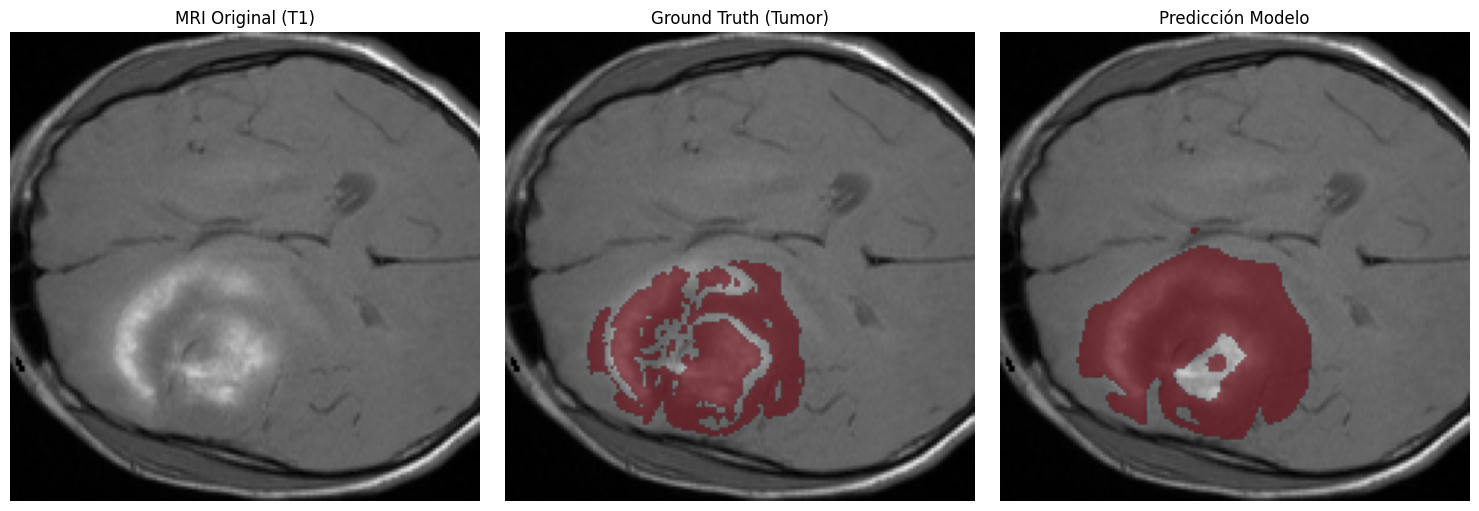

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generar_figura_5_clases(paciente_id, slice_idx):
    # Cargar datos
    data = np.load(f'{output_dir}/rescate_{paciente_id}.npz')
    img = data['x']       # (4, 240, 240, 155)
    y_true = data['y_true'] # (5, 240, 240, 155)
    y_pred = data['y_pred'] # (5, 240, 240, 155)

    # 1. Extraer el slice de la imagen T1
    img_slice = img[0, :, :, slice_idx]

    # 2. Sumar las clases 1 a 4 para obtener la máscara total de tumor
    gt_sum = np.sum(y_true[1:5, :, :, slice_idx], axis=0)
    pred_sum = np.sum(y_pred[1:5, :, :, slice_idx], axis=0)

    # 3. Binarizar: convertimos valores decimales en 1 (tumor) o np.nan (fondo)
    gt_mask = np.where(gt_sum > 0.5, 1.0, np.nan)
    pred_mask = np.where(pred_sum > 0.5, 1.0, np.nan)

    # 4. Crear la figura
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # MRI Original
    axes[0].imshow(img_slice, cmap='gray')
    axes[0].set_title("MRI Original (T1)")
    axes[0].axis('off')

    # Ground Truth (Rojo sólido)
    axes[1].imshow(img_slice, cmap='gray')
    axes[1].imshow(gt_mask, cmap='Reds', alpha=0.6, vmin=0, vmax=1)
    axes[1].set_title("Ground Truth (Tumor)")
    axes[1].axis('off')

    # Predicción (Rojo sólido)
    axes[2].imshow(img_slice, cmap='gray')
    axes[2].imshow(pred_mask, cmap='Reds', alpha=0.6, vmin=0, vmax=1)
    axes[2].set_title("Predicción Modelo")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Ejecución
generar_figura_5_clases('BraTS-PED-00030-000', slice_idx=8)

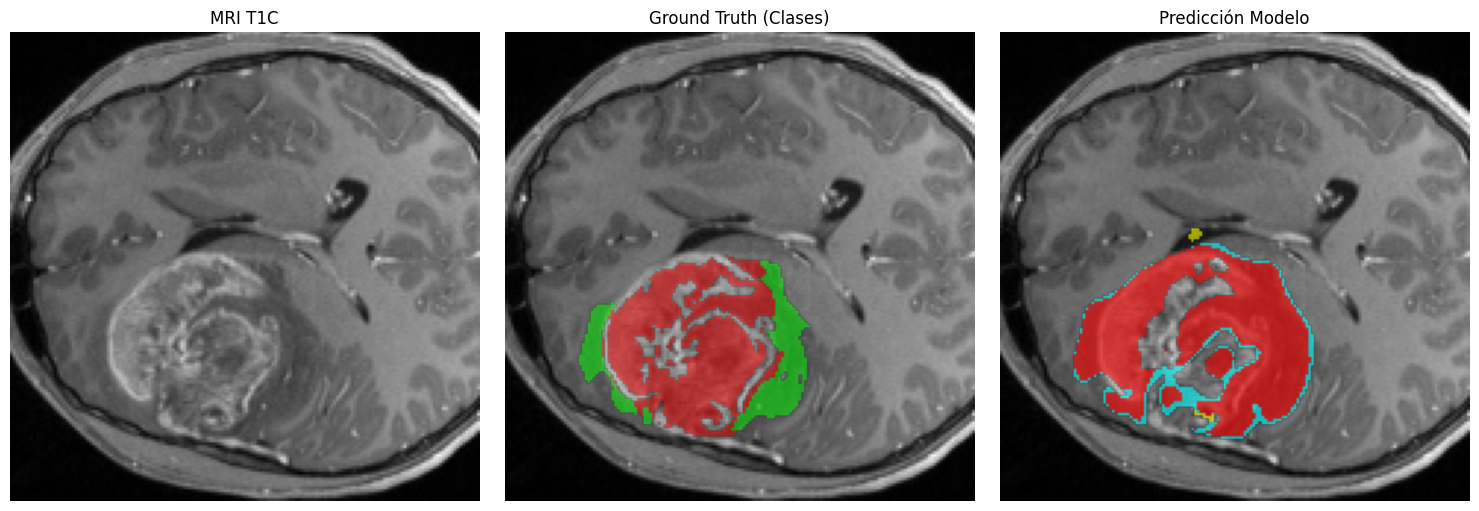

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def generar_figura_colores(paciente_id, slice_idx=8):
    data = np.load(f'{output_dir}/rescate_{paciente_id}.npz')
    y_true = data['y_true']
    y_pred = data['y_pred']
    img_slice = data['x'][1, :, :, slice_idx]

    # Mapa de colores: 0=transparente, 1=Red(ET), 2=Yellow(NET), 3=Cyan(CC), 4=Lime(ED)
    colors = ['none', 'red', 'yellow', 'cyan', 'lime']
    cmap = mcolors.ListedColormap(colors)

    # 1. Obtenemos la máscara de predicción
    pred_mask = np.argmax(y_pred[:, :, :, slice_idx], axis=0)

    # 2. Creamos máscara de confianza: solo mostrar si la prob. de tumor es > 0.3
    # Asumimos que el índice 0 es 'normal/fondo'
    prob_tumor = np.max(y_pred[1:, :, :, slice_idx], axis=0)
    confianza = prob_tumor > 0.3

    # 3. Aplicamos la máscara: si no hay confianza, dejamos el valor como 0 (transparente)
    pred_mask_final = np.zeros_like(pred_mask)
    pred_mask_final[confianza] = pred_mask[confianza]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # MRI Original
    axes[0].imshow(img_slice, cmap='gray')
    axes[0].set_title("MRI T1C")
    axes[0].axis('off')

    # Ground Truth
    gt_mask = np.argmax(y_true[:, :, :, slice_idx], axis=0)
    axes[1].imshow(img_slice, cmap='gray')
    axes[1].imshow(gt_mask, cmap=cmap, alpha=0.5)
    axes[1].set_title("Ground Truth (Clases)")
    axes[1].axis('off')

    # Predicción Corregida
    axes[2].imshow(img_slice, cmap='gray')
    # Usamos alpha=0.6 para que se vea más profesional
    axes[2].imshow(pred_mask_final, cmap=cmap, alpha=0.6, vmin=0, vmax=4)
    axes[2].set_title("Predicción Modelo")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

generar_figura_colores('BraTS-PED-00030-000', slice_idx=10)


In [ ]:
import pandas as pd

# Tu estructura de datos
datos = {
    'Clase 1 (ET)': [0.5167, 0.1209, 0.9952],
    'Clase 2 (NET)': [0.3964, 0.2213, 0.9907],
    'Clase 3 (CC)': [0.4553, 0.0361, 0.9955],
    'Clase 4 (ED)': [0.3129, 0.1162, 0.9807]
}

# Crear el DataFrame y transponerlo (.T) para que las clases sean filas
df = pd.DataFrame(datos, index=['Dice Score', 'Sensibilidad', 'Especificidad']).T

print(df)

               Dice Score  Sensibilidad  Especificidad
Clase 1 (ET)       0.5167        0.1209         0.9952
Clase 2 (NET)      0.3964        0.2213         0.9907
Clase 3 (CC)       0.4553        0.0361         0.9955
Clase 4 (ED)       0.3129        0.1162         0.9807
